# 5. Example: Reading and Writing Data in netCDF format
 
Since you may want to download or generate data from another source, DataAssimBench offers the functionality to import data from netCDF.

### Part I: Download data

First, let's download some example data from: https://www.unidata.ucar.edu/software/netcdf/examples/files.html

In [1]:
import urllib

In [2]:
urllib.request.urlretrieve("https://www.unidata.ucar.edu/software/netcdf/examples/tos_O1_2001-2002.nc", "./tos_01_2001-2002.nc")

('./tos_01_2001-2002.nc', <http.client.HTTPMessage at 0x7f63b9d59e10>)

### Part II: Load data

When loading data from a netCDF, we use the dabench.data.Data class.

Once we define our data object, it's as easy as using the .load_netcdf() method with a specific path.

NOTE: This is a work in progress. Depending on the format of the NetCDF, loading may not work. If you run into issues, open a github issue and we can update the code so that the method loads your NetCDF: https://github.com/StevePny/DataAssimBench/issues

In [3]:
import matplotlib.pyplot as plt
from dabench import data

<frozen abc>:106: FutureWarning: xarray subclass _Vector should explicitly define __slots__
<frozen abc>:106: FutureWarning: xarray subclass StateVector should explicitly define __slots__
<frozen abc>:106: FutureWarning: xarray subclass ObsVector should explicitly define __slots__


In [4]:
data_obj = data.Data()

In [5]:
state_vec = data_obj.load_netcdf('./tos_01_2001-2002.nc')

In [6]:
# In this case, we have 24 months of global sea surface temperature data
# Each cell is 0.5 x 2 degree lat/lon
print(state_vec.coords)
print(state_vec.dims)
print(state_vec.time.shape)

Coordinates:
  * lon        (lon) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 353.0 355.0 357.0 359.0
    lon_bnds   (lon, bnds) float64 3kB ...
  * lat        (lat) float64 1kB -79.5 -78.5 -77.5 -76.5 ... 86.5 87.5 88.5 89.5
    lat_bnds   (lat, bnds) float64 3kB ...
  * time       (time) object 192B 2001-01-16 00:00:00 ... 2002-12-16 00:00:00
    time_bnds  (time, bnds) object 384B ...
FrozenMappingWarningOnValuesAccess({'lon': 180, 'bnds': 2, 'lat': 170, 'time': 24})
(24,)


In [7]:
# The variable that stores the temperature, in this case, is called "tos"
state_vec['tos']

<xarray.DataArray 'tos' (time: 24, lat: 170, lon: 180)> Size: 3MB
[734400 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 353.0 355.0 357.0 359.0
  * lat      (lat) float64 1kB -79.5 -78.5 -77.5 -76.5 ... 86.5 87.5 88.5 89.5
  * time     (time) object 192B 2001-01-16 00:00:00 ... 2002-12-16 00:00:00
Attributes:
    standard_name:   sea_surface_temperature
    long_name:       Sea Surface Temperature
    units:           K
    cell_methods:    time: mean (interval: 30 minutes)
    original_name:   sosstsst
    original_units:  degC
    history:          At   16:37:23 on 01/11/2005: CMOR altered the data in t...

In [8]:
# You can view the variables with state_vec.data_vars
print(state_vec.data_vars)

Data variables:
    tos      (time, lat, lon) float32 3MB ...


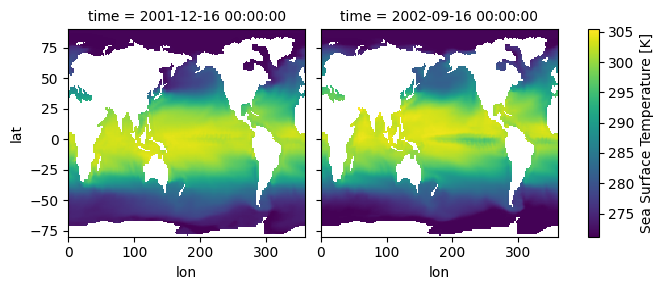

In [9]:
# Plot December 2001 vs September 2002
state_vec.isel(time=[11,20])['tos'].plot(
    x='lon', y='lat', col='time')

In [2]:
import xarray as xr

In [8]:
xr.open_dataset('./tos_01_2001-2002.nc', engine='scipy').as_numpy()

<xarray.Dataset> Size: 3MB
Dimensions:    (lon: 180, bnds: 2, lat: 170, time: 24)
Coordinates:
  * lon        (lon) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 353.0 355.0 357.0 359.0
  * lat        (lat) float64 1kB -79.5 -78.5 -77.5 -76.5 ... 86.5 87.5 88.5 89.5
  * time       (time) object 192B 2001-01-16 00:00:00 ... 2002-12-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    lon_bnds   (lon, bnds) float64 3kB -0.0 2.0 2.0 4.0 ... 358.0 358.0 360.0
    lat_bnds   (lat, bnds) float64 3kB -80.0 -79.0 -79.0 ... 89.0 89.0 90.0
    time_bnds  (time, bnds) object 384B 2001-01-01 00:00:00 ... 2003-01-01 00...
    tos        (time, lat, lon) float32 3MB nan nan nan ... 271.5 271.5 271.5
Attributes: (12/13)
    title:          IPSL  model output prepared for IPCC Fourth Assessment SR...
    institution:    IPSL (Institut Pierre Simon Laplace, Paris, France)
    source:         IPSL-CM4_v1 (2003) : atmosphere : LMDZ (IPSL-CM4_IPCC, 96...
    contact:        Sebastien Denvil, sebastien.denvil@ipsl.jussieu.fr
    project_id:     IPCC Fourth Assessment
    table_id:       Table O1 (13 November 2004)
    ...             ...
    realization:    1
    cmor_version:   0.96
    Conventions:    CF-1.0
    history:        YYYY/MM/JJ: data generated; YYYY/MM/JJ+1 data transformed...
    references:     Dufresne et al, Journal of Climate, 2015, vol XX, p 136
    comment:        Test drive

### Part III: Write Data

We can also write data to netCDF. 

Let's generate some data using Lorenz63 and save to netCDF. See the first example notebook, 1-basics-lorenz63.ipynb, for more detailed discussion of how this data is being generated

In [10]:
l63_model = data.Lorenz63()
l63_sv = l63_model.generate(n_steps=1000)
print(l63_sv['x'].values)

[[-10.         -15.          21.29999924]
 [-10.49983466 -15.48436894  22.28229233]
 [-10.99427504 -15.88440406  23.36066588]
 ...
 [ 14.97283671  18.04519819  32.55729151]
 [ 15.21899866  17.04571187  34.31892339]
 [ 15.3340581   15.79191029  35.89525082]]


In [12]:
l63_model.save_netcdf(l63_sv, './l63_data.nc')

In [18]:
# Now let's reload that data we just wrote to file
reload_l63 = data.Data().load_netcdf('./l63_data.nc')
# And check to make sure that it's the same as the data we generated
reload_l63['x'].values

array([[-10.        , -15.        ,  21.29999924],
       [-10.49983466, -15.48436894,  22.28229233],
       [-10.99427504, -15.88440406,  23.36066588],
       ...,
       [ 14.97283671,  18.04519819,  32.55729151],
       [ 15.21899866,  17.04571187,  34.31892339],
       [ 15.3340581 ,  15.79191029,  35.89525082]])

Looks good!